In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

PROCESSED = r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\data\processed\\'
REPORTS = r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\reports\\'

In [2]:
df = pd.read_csv(PROCESSED + 'sales_features.csv', parse_dates=['date'])
print(df.shape)
df.head()

(216987, 24)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,event_name_1,...,dayofweek,quarter,is_weekend,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,is_event
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_40,2,2011-03-09,LentStart,...,2,1,0,1.0,2.0,0.0,2.142857,2.071429,1.714286,1
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_47,1,2011-03-16,LentWeek2,...,2,1,0,2.0,1.0,2.0,1.571429,1.857143,1.750000,1
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_48,0,2011-03-17,StPatricksDay,...,3,1,0,3.0,7.0,0.0,1.428571,1.857143,1.714286,1
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_51,1,2011-03-20,Purim End,...,6,1,1,5.0,3.0,2.0,1.000000,1.214286,1.642857,1
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_86,0,2011-04-24,OrthodoxEaster,...,6,2,1,2.0,2.0,2.0,0.714286,1.000000,0.821429,1


In [3]:
le = LabelEncoder()
df['item_id_enc'] = le.fit_transform(df['item_id'])
df['dept_id_enc'] = le.fit_transform(df['dept_id'])

feature_cols = ['item_id_enc', 'dept_id_enc',
                'year', 'month', 'week', 'dayofweek',
                'quarter', 'is_weekend', 'is_event',
                'snap_CA', 'lag_7', 'lag_14', 'lag_28',
                'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']

X = df[feature_cols]
y = df['sales']
print(X.shape)

(216987, 16)


In [4]:
split_date = '2015-12-31'
train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

X_train = train[feature_cols]
y_train = train['sales']
X_test = test[feature_cols]
y_test = test['sales']

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (201180, 16)
Test: (15807, 16)


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"Linear Regression → MAE: {lr_mae:.2f} | RMSE: {lr_rmse:.2f}")

Linear Regression → MAE: 1.29 | RMSE: 2.40


In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest → MAE: {rf_mae:.2f} | RMSE: {rf_rmse:.2f}")

Random Forest → MAE: 1.30 | RMSE: 2.38


In [7]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"Gradient Boosting → MAE: {gb_mae:.2f} | RMSE: {gb_rmse:.2f}")

Gradient Boosting → MAE: 1.24 | RMSE: 2.34


               Model       MAE      RMSE
0  Linear Regression  1.293015  2.402605
1      Random Forest  1.299574  2.379326
2  Gradient Boosting  1.239259  2.342729


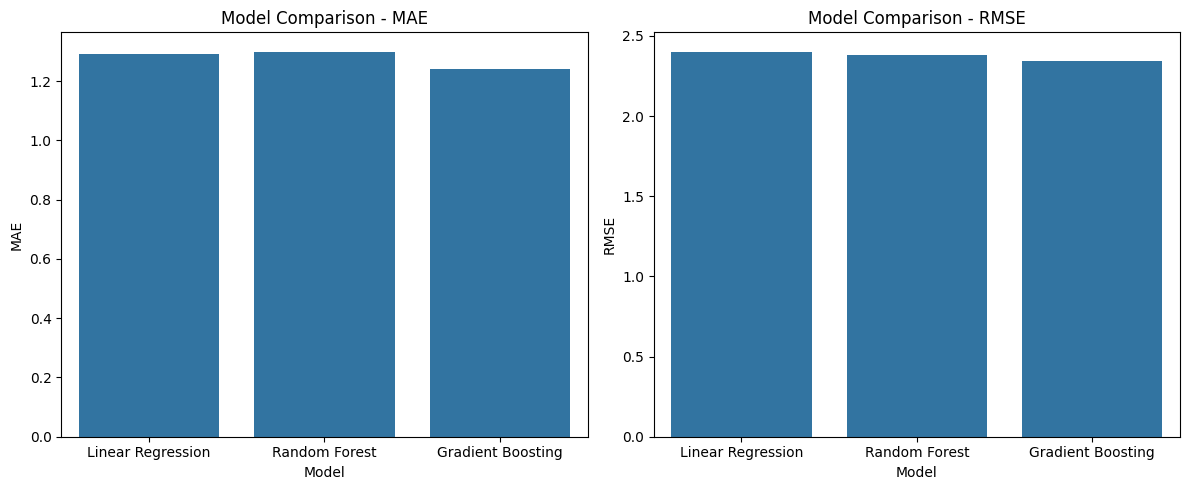

In [8]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
})

print(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=results, x='Model', y='MAE', ax=axes[0])
axes[0].set_title('Model Comparison - MAE')
sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1])
axes[1].set_title('Model Comparison - RMSE')
plt.tight_layout()
plt.savefig(REPORTS + 'model_comparison.png')
plt.show()

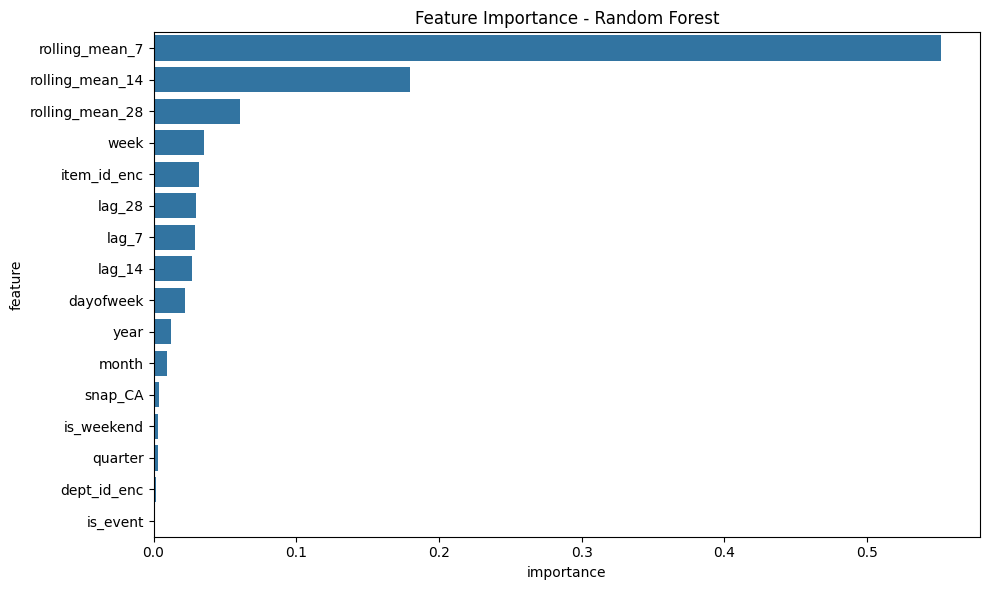

In [9]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig(REPORTS + 'feature_importance.png')
plt.show()

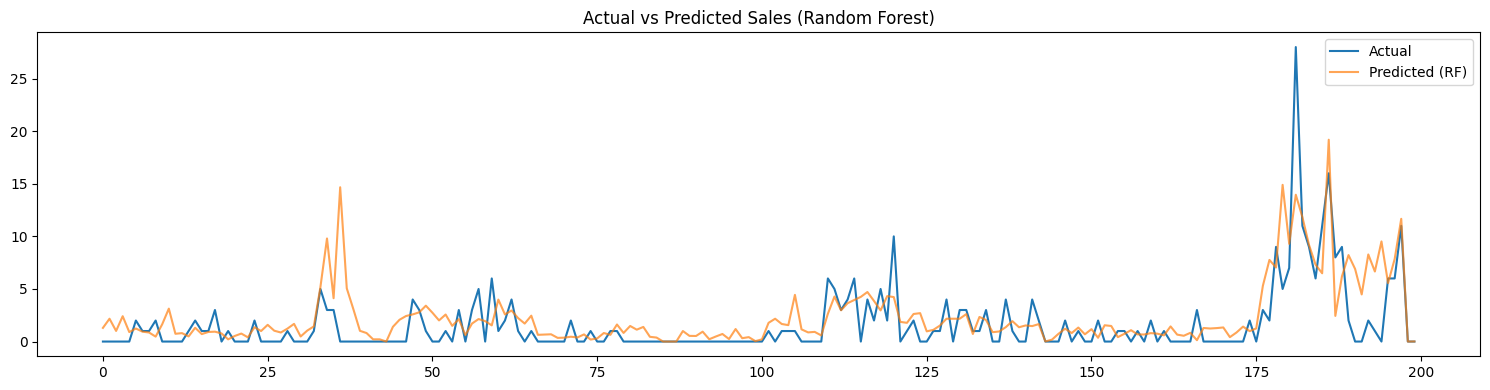

In [10]:
plt.figure(figsize=(15, 4))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(rf_pred[:200], label='Predicted (RF)', alpha=0.7)
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS + 'actual_vs_predicted.png')
plt.show()